# ============================================================
# Differentially Private Synthetic Data Generation
# Method: MST
# Dataset: Adult Income Dataset
# ============================================================

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import time
import warnings
warnings.filterwarnings('ignore')


In [6]:
# ── 1. 載入資料 ──────────────────────────────────────────────
df = pd.read_csv("adult.csv")
print(f"原始資料: {df.shape}")

原始資料: (48842, 15)


In [7]:
# ── 2. 前處理 ─────────────────────────────────────────────────
# 移除 fnlwgt（權重欄位，非個人屬性）
df = df.drop(columns=['fnlwgt'])

# 類別欄位
cat_cols = ['workclass','education','marital-status','occupation',
            'relationship','race','gender','native-country','income']
num_cols = ['age','educational-num','capital-gain','capital-loss','hours-per-week']

In [8]:
# ── 3. 使用 MST 產生 Synthetic Data ─────────────────────
from snsynth import Synthesizer

EPSILON_LIST = [0.1, 0.5, 1.0, 5.0, 10.0]  # 測試不同隱私預算
results = {}

for eps in EPSILON_LIST:
    print(f"\n[ε={eps}] 開始生成合成資料...")
    start = time.time()

    synth = Synthesizer.create("mst", epsilon=eps)
    synth.fit(df, preprocessor_eps=eps * 0.1)  # 10% 預算給前處理
    synthetic_df = synth.sample(len(df))

    elapsed = time.time() - start
    print(f"  完成！耗時 {elapsed:.1f}s，生成 {len(synthetic_df)} 筆")

    synthetic_df.to_csv(f"./DP_Adult/adult_dp_eps{eps}.csv", index=False)
    results[eps] = {'df': synthetic_df, 'time': elapsed}


[ε=0.1] 開始生成合成資料...
Spent 0.010000000000000002 epsilon on preprocessor, leaving 0.09 for training
  完成！耗時 26.2s，生成 48842 筆

[ε=0.5] 開始生成合成資料...
Spent 0.05 epsilon on preprocessor, leaving 0.45 for training
  完成！耗時 23.5s，生成 48842 筆

[ε=1.0] 開始生成合成資料...
Spent 0.1 epsilon on preprocessor, leaving 0.9 for training
  完成！耗時 20.3s，生成 48842 筆

[ε=5.0] 開始生成合成資料...
Spent 0.5 epsilon on preprocessor, leaving 4.5 for training
  完成！耗時 22.1s，生成 48842 筆

[ε=10.0] 開始生成合成資料...
Spent 1.0 epsilon on preprocessor, leaving 9.0 for training
  完成！耗時 22.7s，生成 48842 筆


In [9]:
# ── 4. 評估：ML Utility（分類準確率）────────────────────────────
def evaluate_ml_utility(train_df, test_df, label='income'):
    """Train on synthetic, test on real — 標準 utility 評估"""
    le = LabelEncoder()
    
    def encode(df):
        d = df.copy()
        for col in d.select_dtypes('object').columns:
            d[col] = le.fit_transform(d[col].astype(str))
        return d
    
    train_enc = encode(train_df)
    test_enc  = encode(test_df)
    
    X_train = train_enc.drop(columns=[label])
    y_train = train_enc[label]
    X_test  = test_enc.drop(columns=[label])
    y_test  = test_enc[label]
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    return accuracy_score(y_test, clf.predict(X_test))

# 原始資料 baseline
X_real, X_test_real, y_real, y_test_real = train_test_split(
    df.drop(columns=['income']), df['income'], test_size=0.2, random_state=42)

real_train_df = pd.concat([X_real, y_real], axis=1)
real_test_df  = pd.concat([X_test_real, y_test_real], axis=1)
baseline_acc  = evaluate_ml_utility(real_train_df, real_test_df)
print(f"\nBaseline (real→real): {baseline_acc:.4f}")

# 各 epsilon 的 accuracy
acc_results = {'Baseline': baseline_acc}
for eps, r in results.items():
    acc = evaluate_ml_utility(r['df'], real_test_df)
    acc_results[f'ε={eps}'] = acc
    print(f"  ε={eps}: {acc:.4f}")


Baseline (real→real): 0.8563
  ε=0.1: 0.7088
  ε=0.5: 0.7574
  ε=1.0: 0.7410
  ε=5.0: 0.7733
  ε=10.0: 0.7665


In [10]:
# ── 5. 評估：統計相似性（邊際分佈差異）──────────────────────────
def marginal_similarity(real_df, syn_df, col):
    """比較單欄位的分佈差異（TVD）"""
    if real_df[col].dtype == 'object':
        real_dist = real_df[col].value_counts(normalize=True)
        syn_dist  = syn_df[col].value_counts(normalize=True)
        idx = real_dist.index.union(syn_dist.index)
        tvd = 0.5 * abs(real_dist.reindex(idx, fill_value=0) -
                        syn_dist.reindex(idx, fill_value=0)).sum()
    else:
        bins = np.linspace(real_df[col].min(), real_df[col].max(), 20)
        r, _ = np.histogram(real_df[col], bins=bins, density=True)
        s, _ = np.histogram(syn_df[col],  bins=bins, density=True)
        tvd = 0.5 * abs(r - s).sum() * (bins[1]-bins[0])
    return tvd

tvd_results = {}
for eps, r in results.items():
    tvds = [marginal_similarity(df, r['df'], c) for c in df.columns]
    tvd_results[eps] = np.mean(tvds)
    print(f"  ε={eps} 平均 TVD: {tvd_results[eps]:.4f}")


  ε=0.1 平均 TVD: 0.0500
  ε=0.5 平均 TVD: 0.0117
  ε=1.0 平均 TVD: 0.0067
  ε=5.0 平均 TVD: 0.0712
  ε=10.0 平均 TVD: 0.0708


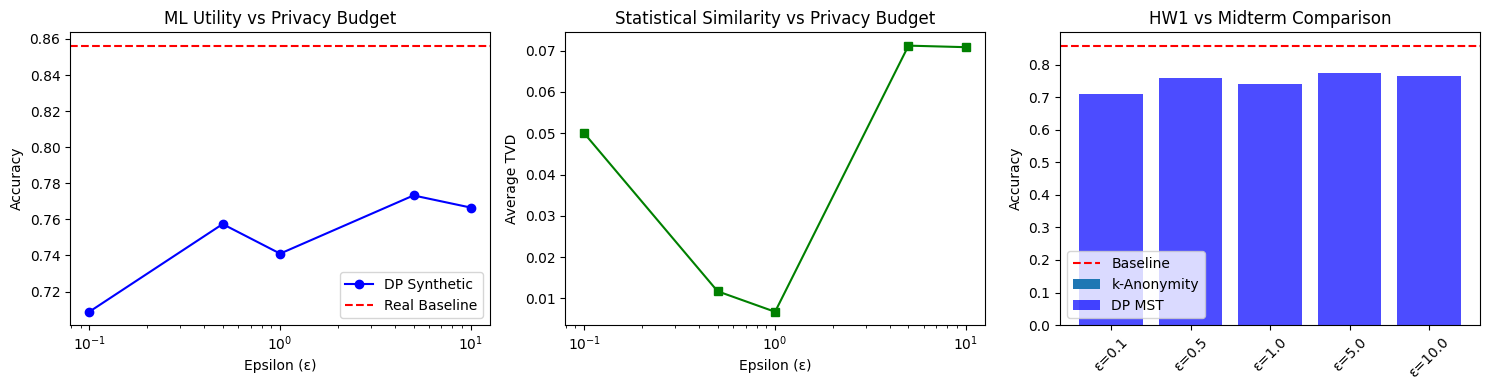

圖表已儲存：comparison_results.png


In [11]:
# ── 6. 畫圖 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 圖1: Accuracy vs Epsilon
epsilons = list(results.keys())
accs = [acc_results[f'ε={e}'] for e in epsilons]
axes[0].plot(epsilons, accs, 'b-o', label='DP Synthetic')
axes[0].axhline(baseline_acc, color='r', linestyle='--', label='Real Baseline')
axes[0].set_xlabel('Epsilon (ε)'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('ML Utility vs Privacy Budget'); axes[0].legend()
axes[0].set_xscale('log')

# 圖2: TVD vs Epsilon（統計相似性）
tvds = [tvd_results[e] for e in epsilons]
axes[1].plot(epsilons, tvds, 'g-s')
axes[1].set_xlabel('Epsilon (ε)'); axes[1].set_ylabel('Average TVD')
axes[1].set_title('Statistical Similarity vs Privacy Budget')
axes[1].set_xscale('log')

# 圖3: 比較 HW1 k-anonymity vs DP（分類準確率）
k_anon_files = {2:'adult_k2.csv', 5:'adult_k5.csv', 10:'adult_k10.csv',
                25:'adult_k25.csv', 50:'adult_k50.csv'}
k_accs = {}
for k, fname in k_anon_files.items():
    try:
        k_df = pd.read_csv(fname)
        k_accs[k] = evaluate_ml_utility(k_df, real_test_df)
    except: pass

axes[2].bar([f'k={k}' for k in k_accs], list(k_accs.values()),
            color='orange', label='k-Anonymity')
axes[2].bar([f'ε={e}' for e in epsilons], accs, 
            color='blue', alpha=0.7, label='DP MST')
axes[2].axhline(baseline_acc, color='r', linestyle='--', label='Baseline')
axes[2].set_ylabel('Accuracy'); axes[2].set_title('HW1 vs Midterm Comparison')
axes[2].legend(); axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150)
plt.show()
print("圖表已儲存：comparison_results.png")